In [13]:
import pandas as pd
import wbgapi as wb
import numpy as np

In [55]:
import requests, re
import json
import matplotlib.pyplot as plt

In [169]:
investment_I = wb.data.DataFrame('NE.GDI.FTOT.CD','JPN', range(2005,2023)).transpose()

In [149]:
govSpend_G= wb.data.DataFrame('NE.CON.GOVT.CD','JPN', range(2005,2023)).transpose()

In [191]:
imports_IM = wb.data.DataFrame('NE.IMP.GNFS.CD','JPN', range(2005,2023)).transpose()

In [25]:
exports_X = wb.data.DataFrame('NE.EXP.GNFS.CD','JPN', range(2005,2023)).transpose()

In [27]:
disposableIncome_Y=(wb.data.DataFrame('NY.GDS.TOTL.CN','JPN', range(2005,2023)).transpose())/1000000

In [151]:
Reserves = wb.data.DataFrame('FI.RES.TOTL.CD','JPN', range(1990,2024)).transpose()*1000

In [149]:
Deposits = wb.data.DataFrame('FM.LBL.BMNY.CN','JPN', range(1990,2024)).transpose()

In [153]:
Deposits.columns = ['Deposits']
Reserves.columns = ['Reserves']
merged_data = pd.merge(Reserves, Deposits, left_index=True, right_index=True)
cross_corr = merged_data['Reserves'].corr(merged_data['Deposits'])
print(f"Cross-correlation between Reserves and Deposits in Japan (2005-2020): {cross_corr:.4f}")

Cross-correlation between Reserves and Deposits in Japan (2005-2020): 0.6788


<Axes: >

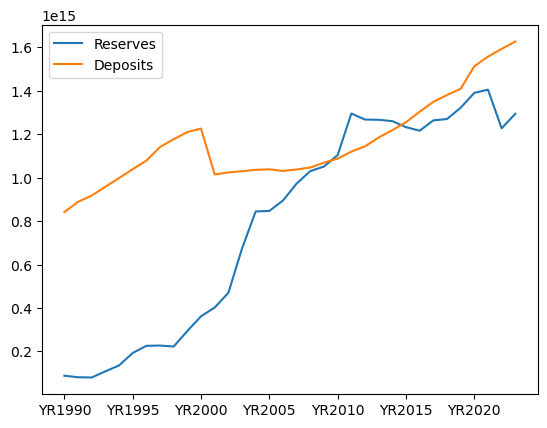

In [163]:
merged_data.plot()

In [17]:
s = wb.search('deposits')
print(s)

Series: BX.TRF.PWKR.DT.GD.ZS

Othernotes: ...actual transfers rather than imports. Second, in many countries, nonresident deposits, although classified under the capital account, may in part reflect workers’...
Series: FB.AST.LOAN.MF.P3

Longdefinition: ...are institutions whose primary business model is to lend to (and possibly take deposits from) the poor, often using specialized methodologies such as group lending....
--------
Shortdefinition: ...are institutions whose primary business model is to lend to (and possibly take deposits from) the poor, often using specialized methodologies such as group lending....
Series: FB.BNK.BRCH.MF.P5

Longdefinition: ...are institutions whose primary business model is to lend to (and possibly take deposits from) the poor, often using specialized methodologies such as group lending....
--------
Shortdefinition: ...are institutions whose primary business model is to lend to (and possibly take deposits from) the poor, often using specialized methodo

In [19]:
investment_I.columns = ['Investment']
govSpend_G.columns = ['Government Spending']

NameError: name 'investment_I' is not defined

In [21]:
combined_data = pd.concat([investment_I, govSpend_G], axis=1)

NameError: name 'investment_I' is not defined

In [23]:
series = 'IFS' # International Financial Statistics
period = 'Q' # Q, M, A for quarterly, monthly or annually statistics
country = 'US' # two letter country code
time_start = 2010
time_end = 2023

In [25]:
search_term = 'consumption'

In [27]:
key = f'DataStructure/{series}'
url = 'http://dataservices.imf.org/REST/SDMX_JSON.svc/'

dimension_list = requests.get(f'{url}{key}').json()['Structure']['KeyFamilies']['KeyFamily']['Components']['Dimension']

key = f"CodeList/{dimension_list[2]['@codelist']}"

code_list = requests.get(f'{url}{key}').json()['Structure']['CodeLists']['CodeList']['Code']

# create a disctionary of index codes and corresponding names
code_dict = {}

for code in code_list:
    if (search_term in code['Description']['#text'].lower()):
        code_dict[code['@value']] = code['Description']['#text']

# print dictionary
code_dict

{'NC_XDC': 'Final Consumption Expenditure, Nominal, Domestic Currency',
 'NC_SA_XDC': 'Final Consumption Expenditure, Nominal, Seasonally Adjusted, Domestic Currency',
 'NC_NSA_XDC': 'Final Consumption Expenditure, Nominal, Unadjusted, Domestic Currency',
 'NC_R_XDC': 'Final Consumption Expenditure, Real, Domestic Currency',
 'NC_R_SA_XDC': 'Final Consumption Expenditure, Real, Seasonally Adjusted, Domestic Currency',
 'NC_R_NSA_XDC': 'Final Consumption Expenditure, Real, Unadjusted, Domestic Currency',
 'FIHN_HH_L_CO_1Y_PA': 'Financial, Interest Rates, Harmonized Euro Area Rates, New Business, Loans, Households, Consumption, Floating Rate and up to 1 Year, Percent per annum',
 'BCG_GADANKC_T_G01_XDC': 'Budgetary Central Government, Consumption of fixed capital [=23], Domestic Currency',
 'BCG_GEKC_G01_XDC': 'Fiscal, Budgetary Central Government, Expense, Consumption of Fixed Capital, 2001 Manual, Domestic Currency',
 'CG01_GADANKC_T_G01_XDC': 'Central Government (including Social Secu

In [29]:
code = 'NGDP_R_SA_XDC' # Gross Domestic Product, Real, Seasonally Adjusted, Domestic Currency

In [73]:
name = code_dict[code]

In [31]:
def _download_imf_ts(series=series, period=period, country=country, code=code, time_start=2000, time_end=time_end):
   
   # building the url to access the RESTful API
    base = f'http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/{series}/'
    time = f'?startPeriod={time_start}&endPeriod={time_end}'
    url = f'{base}{period}.{country}.{code}.{time}'
    #print(url)
    rq = requests.get(url)
    if rq.status_code == 200:
        try:
            response = rq.json()
            #print(response)
            series = response['CompactData']['DataSet']['Series']
            #print(series)
            temp_dic = series.get('Obs')
            #print(temp_dic)
            df = pd.DataFrame.from_dict(temp_dic).rename( 
                    columns = {
                        '@OBS_VALUE' : 'Value',
                        '@OBS_STATUS': 'Status'
                    }
            )
            df['Country'] = series.get('@REF_AREA')
            df['Indicator'] = series.get('@INDICATOR')

            df['Period'] = pd.to_datetime([row.replace('-', '') for row in df['@TIME_PERIOD']])
            df.drop('@TIME_PERIOD', axis=1, inplace=True)

            df["Value"] = df["Value"].astype("double")
            df = df[['Indicator', 'Country', 'Period', 'Value']]

        except:
            print(f"Error for {country} {code}: {url}")
            df = pd.DataFrame()
    return df

In [77]:
df = download_imf_ts(series=series, period=period, country=country, code=code, name=name, time_start=time_start, time_end=time_end)

Error for US NGDP_R_SA_XDC: http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/IFS/Q.US.NGDP_R_SA_XDC?startPeriod=2010&endPeriod=2023


In [57]:
url = "http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/IFS/Q.US.NC_R_XDC?startPeriod=2010&endPeriod=2023"
data = requests.get(url).json()

print(data) 

{'CompactData': {'@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance', '@xmlns:xsd': 'http://www.w3.org/2001/XMLSchema', '@xsi:schemaLocation': 'http://www.SDMX.org/resources/SDMXML/schemas/v2_0/message https://registry.sdmx.org/schemas/v2_0/SDMXMessage.xsd http://dataservices.imf.org/compact/IFS http://dataservices.imf.org/compact/IFS.xsd', '@xmlns': 'http://www.SDMX.org/resources/SDMXML/schemas/v2_0/message', 'Header': {'ID': 'ec64f748-0c97-4199-8d59-0262f8d9b54c', 'Test': 'false', 'Prepared': '2025-03-26T10:16:57', 'Sender': {'@id': '1C0', 'Name': {'@xml:lang': 'en', '#text': 'IMF'}, 'Contact': {'URI': 'http://www.imf.org', 'Telephone': '+ 1 (202) 623-6220'}}, 'Receiver': {'@id': 'ZZZ'}, 'DataSetID': 'IFS'}, 'DataSet': {'@xmlns': 'http://dataservices.imf.org/compact/IFS'}}}


In [59]:
data

{'CompactData': {'@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance',
  '@xmlns:xsd': 'http://www.w3.org/2001/XMLSchema',
  '@xsi:schemaLocation': 'http://www.SDMX.org/resources/SDMXML/schemas/v2_0/message https://registry.sdmx.org/schemas/v2_0/SDMXMessage.xsd http://dataservices.imf.org/compact/IFS http://dataservices.imf.org/compact/IFS.xsd',
  '@xmlns': 'http://www.SDMX.org/resources/SDMXML/schemas/v2_0/message',
  'Header': {'ID': 'ec64f748-0c97-4199-8d59-0262f8d9b54c',
   'Test': 'false',
   'Prepared': '2025-03-26T10:16:57',
   'Sender': {'@id': '1C0',
    'Name': {'@xml:lang': 'en', '#text': 'IMF'},
    'Contact': {'URI': 'http://www.imf.org',
     'Telephone': '+ 1 (202) 623-6220'}},
   'Receiver': {'@id': 'ZZZ'},
   'DataSetID': 'IFS'},
  'DataSet': {'@xmlns': 'http://dataservices.imf.org/compact/IFS'}}}